In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 데이터 생성
np.random.seed(0)
N, D = 1000, 4  # 샘플 수, 특성 수
X = np.random.rand(N, D)
w_true = np.random.rand(D)
noise = 0.1 * np.random.randn(N)
y = X @ w_true + noise

In [ ]:
# 선형 회귀 해 계산
w_pred = np.linalg.inv(X.T @ X) @ X.T @ y
y_pred = X @ w_pred

# 오차 계산
estimation_error = np.mean((y - y_pred) ** 2)
weight_error = np.linalg.norm(w_pred - w_true)
# 결과 출력
print("True Weights:      ", w_true)
print("Estimated Weights: ", w_pred)
print("Weight Error (L2): ", weight_error)
print("Estimation Error:  ", estimation_error)

True Weights:       [0.29264205 0.56651827 0.13741443 0.34971218]
Estimated Weights:  [0.30320749 0.56195512 0.1178718  0.35630279]
Weight Error (L2):  0.023617811703325022
Estimation Error:   0.01027829655830962


   Optimizer  Batch Type Init Type  Estimation Error  Weight Error
0         GD         SGD    random          0.010076      0.095096
1         GD         SGD    sparse          0.004776      0.113207
2         GD         SGD      zero          0.003071      0.096848
3         GD        full    random          0.010278      0.023618
4         GD        full    sparse          0.010278      0.023618
5         GD        full      zero          0.010278      0.023618
6         GD  mini-batch    random          0.011680      0.023311
7         GD  mini-batch    sparse          0.011680      0.023310
8         GD  mini-batch      zero          0.011680      0.023310
9    AdaGrad         SGD    random          0.000559      0.501811
10   AdaGrad         SGD    sparse          0.015135      0.204853
11   AdaGrad         SGD      zero          0.003532      0.038763
12   AdaGrad        full    random          0.012392      0.177239
13   AdaGrad        full    sparse          0.010278      0.02

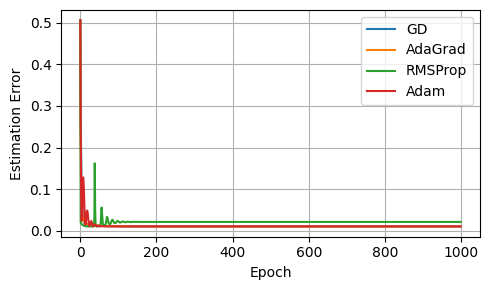

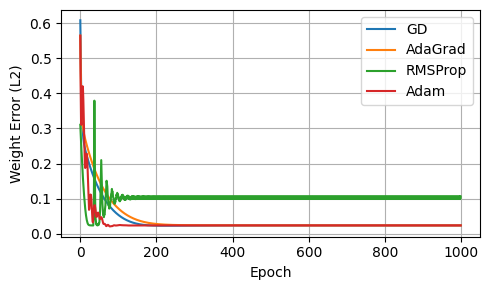

In [ ]:
#################### Gradient Descent error estimation ########################
def run_experiment(init_type, batch_type, optimizer_type, learning_rate=0.1, num_epochs=1000, batch_size=32):
    np.random.seed(0)

    # 가중치 초기화
    if init_type == 'random':
        w = np.random.randn(D)
    elif init_type == 'zero':
        w = np.zeros(D)
    elif init_type == 'sparse':
        w = np.random.randn(D)
        w[np.random.rand(D) < 0.8] = 0

    # 옵티마이저 변수 초기화
    m = v = grad_squared = running_avg = np.zeros_like(w)
    beta1, beta2, epsilon = 0.9, 0.999, 1e-8
    error_history = []
    weight_error_history = []

    # 학습 루프
    for epoch in range(1, num_epochs + 1):
        # 배치 선택
        if batch_type == 'full':
            X_batch, y_batch = X, y
        elif batch_type == 'mini-batch':
            idx = np.random.choice(N, batch_size, replace=False)
            X_batch, y_batch = X[idx], y[idx]
        elif batch_type == 'SGD':
            idx = np.random.randint(0, N)
            X_batch, y_batch = X[idx:idx+1], y[idx:idx+1]

        # 예측 및 그래디언트 계산
        y_pred = X_batch @ w
        error = y_pred - y_batch
        grad = (2 / X_batch.shape[0]) * X_batch.T @ error

        # 옵티마이저별 업데이트
        if optimizer_type == 'GD':
            w -= learning_rate * grad
        elif optimizer_type == 'AdaGrad':
            grad_squared += grad ** 2
            w -= learning_rate * grad / (np.sqrt(grad_squared) + epsilon)
        elif optimizer_type == 'RMSProp':
            running_avg = 0.9 * running_avg + 0.1 * (grad ** 2)
            w -= learning_rate * grad / (np.sqrt(running_avg) + epsilon)
        elif optimizer_type == 'Adam':
            m = beta1 * m + (1 - beta1) * grad
            v = beta2 * v + (1 - beta2) * (grad ** 2)
            m_hat = m / (1 - beta1 ** epoch)
            v_hat = v / (1 - beta2 ** epoch)
            w -= learning_rate * m_hat / (np.sqrt(v_hat) + epsilon)

        # 에러 저장
        error_history.append(np.mean((y_batch - y_pred) ** 2))
        weight_error_history.append(np.linalg.norm(w - w_true))

    return error_history[-1], error_history, weight_error_history[-1], weight_error_history

# 3. 전체 실험 실행
results, history_dict = [], {}

for init in ['random', 'zero', 'sparse']:
    for batch in ['full', 'mini-batch', 'SGD']:
        for opt in ['GD', 'AdaGrad', 'RMSProp', 'Adam']:
            final_err, hist, final_err_weight,hist_weight = run_experiment(init, batch, opt)
            results.append({
                'Init Type': init, 'Batch Type': batch,
                'Optimizer': opt, 'Estimation Error': final_err, 'Weight Error': final_err_weight
            })
            history_dict[(opt, batch, init)] = {'estimation': hist, 'weight': hist_weight}

# 4. 결과 정리 및 출력
df = pd.DataFrame(results)[['Optimizer', 'Batch Type', 'Init Type', 'Estimation Error','Weight Error']]
df['Optimizer'] = pd.Categorical(df['Optimizer'], categories=['GD', 'AdaGrad', 'RMSProp', 'Adam'], ordered=True)
df = df.sort_values(by=['Optimizer', 'Batch Type', 'Init Type']).reset_index(drop=True)
print(df)

# 시각화
selected_init, selected_batch = 'zero', 'full'
### estimation error ###
plt.figure(figsize=(5, 3))
for opt in ['GD', 'AdaGrad', 'RMSProp', 'Adam']:
    key = (opt, selected_batch, selected_init)
    if key in history_dict:
        plt.plot(history_dict[key]['estimation'], label=opt)
plt.xlabel('Epoch')
plt.ylabel('Estimation Error')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

### weight error ###
plt.figure(figsize=(5, 3))
for opt in ['GD', 'AdaGrad', 'RMSProp', 'Adam']:
    key = (opt, selected_batch, selected_init)
    if key in history_dict:
        plt.plot(history_dict[key]['weight'], label=opt)
plt.xlabel('Epoch')
plt.ylabel('Weight Error (L2)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()